##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 2

**Group name:** Timo & Jakub

**Student names & numbers:**
* Timo Storny - 00099699
* Jakub Holik - 00099393


---

## 0. Iteration setup

**Import libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

**Load and merge datasets**

In [2]:
# CODE CELL: import the necessary datasets for this iteration
# Make sure to load your cleaned dataset from Iteration 1 AND the new inspection data for Iteration 2.
# Merge them together based on the Ship_ID.
df_ship_inventory = pd.read_csv('ship_inventory.csv')
df_ship_inspection = pd.read_csv('ship_inspections_iter2.csv')

df_merged = df_ship_inventory.merge(df_ship_inspection, left_on="Ship_ID", right_on="Ship_ID", how="left")
df_merged.head()

,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class
0,7316160254,4950,7505.0,Galactic Motors,Mon Cala Ocean Worlds,Critical,40.0,Ion Drive,Shuttle
1,7316115206,18999,7518.0,Galactic Motors,Thraxos Blockade,Pristine,120.0,Solar Sail,Shuttle
2,7315865657,4000,7486.0,Republic Aerospace,Indoumodo Sector,Critical,40.0,Ion Drive,Shuttle
3,7314772431,6495,7511.0,Nebula Industries,Pantora Moon,Pristine,40.0,Graviton Beam,Shuttle
4,7311539325,3995,7499.0,Corellian Engineering,Malastare Narrows,Critical,40.0,Hyperdrive,Shuttle


---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**

*Describe the problem surrounding the safety inspections. Why is the current process (human estimation/gut feeling) a risk?*

**Business objective(s)**

*Justify why a standardized, rule-based expert system is needed.*

**Data mining goal(s)**

*Explain what type of modeling task this is and why.*

**Success criteria**

*Determine success criteria for this iteration*

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Show the summary statistics and describe the new variables (e.g., Propulsion_Type, Reactor_Power, Hull_Integrity). Describe your findings.*

In [4]:
# CODE CELL: Show basic statistics and information
df_merged.info()
df_merged.describe()

<class 'pandas.DataFrame'>
RangeIndex: 368814 entries, 0 to 368813
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Ship_ID            368814 non-null  int64  
 1   Galactic_Credits   368814 non-null  int64  
 2   Model_Cycle        361408 non-null  float64
 3   Ship_Manufacturer  368814 non-null  str    
 4   Sector             368814 non-null  str    
 5   Hull_Integrity     368814 non-null  str    
 6   Reactor_Power      339345 non-null  float64
 7   Propulsion_Type    312108 non-null  str    
 8   Ship_Class         368814 non-null  str    
dtypes: float64(2), int64(2), str(5)
memory usage: 25.3 MB


,Ship_ID,Galactic_Credits,Model_Cycle,Reactor_Power
count,3.688140e+05,368814.000000,361408.000000,339345.000000
mean,7.311485e+09,19453.536818,7511.264529,71.590535
std,4.381124e+06,15540.472943,9.078571,44.649937
min,7.301583e+09,501.000000,7400.000000,30.000000
25%,7.308105e+09,7950.000000,7508.000000,40.000000
50%,7.312604e+09,15990.000000,7513.000000,60.000000
75%,7.315245e+09,27990.000000,7517.000000,80.000000
max,7.317101e+09,777777.000000,7522.000000,360.000000


**Visualizations and patterns**

*Discover patterns in the data that will help you determine the inspection rules. Create visualizations that show the relationship between variables like Reactor_Power, Propulsion_Type, Ship_Class on one side, and the target variable Hull_Integrity on the other. Describe any hard rules you discover (e.g., relationships with dangerous reactors or advanced tech).*

<Axes: xlabel='Hull_Integrity', ylabel='Reactor_Power'>

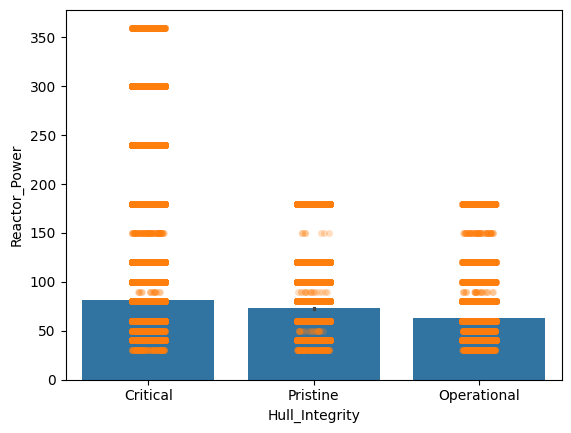

In [31]:
# CODE CELL: Generate visualizations (e.g., bar charts, boxplots comparing features against Hull_Integrity)
sns.barplot(data=df_merged, x="Hull_Integrity", y="Reactor_Power", estimator='mean')
sns.stripplot(data=df_merged, x="Hull_Integrity", y="Reactor_Power", alpha=0.25, jitter=True)
#sns.boxplot(data=df_merged, x="Hull_Integrity", y="Reactor_Power")

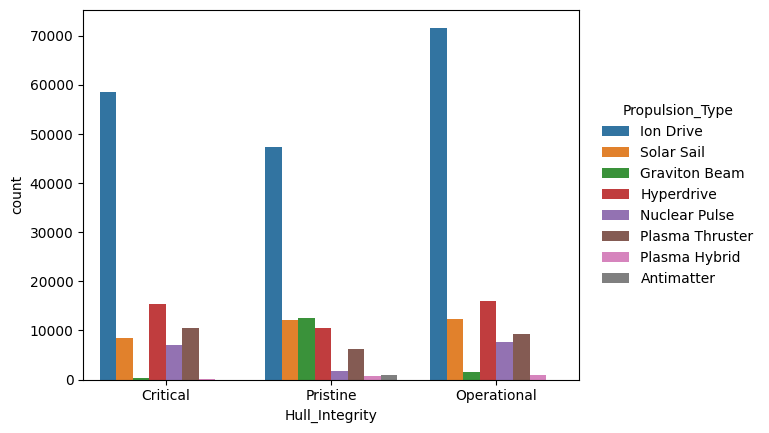

In [19]:
ax = sns.countplot(data=df_merged, x="Hull_Integrity", hue="Propulsion_Type")
sns.move_legend(ax, "center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

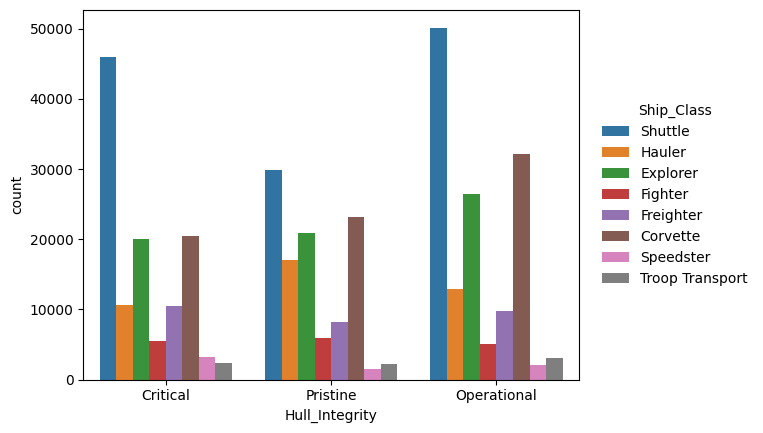

In [18]:
ax = sns.countplot(data=df_merged, x="Hull_Integrity", hue="Ship_Class")
sns.move_legend(ax, "center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

**Data insights and data quality**
* **Insights:** What clear rules/patterns did you find that we can use for classification later?
* **Quality issues:** Document missing values (specifically in Propulsion and Reactor) and outliers.

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify how you resolve the missing values.*

In [ ]:
# CODE CELL: Data cleaning, preprocessing

**Adjusting dataset (optional)**
*If you adjusted the dataset for modeling in additional ways, describe that here*

In [5]:
# OPTIONAL CODE CELL: Additional preprocessing steps

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Build a manual classifier. Use the insights from step 2 to write a Python function with if/elif/else statements that predicts the Hull_Condition for each ship. Apply this function to your dataset and save the predictions in a new column.*

In [ ]:
# CODE CELL: Model training and setup code

**Testing and performance**
*Evaluate your manual rules. Calculate the metrics and generate a **confusion matrix** (visualize this using seaborn/matplotlib).*

In [1]:
# CODE CELL: Model evaluation code

---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*How well does your manual model identify 'Critical' or 'Pristine' ships? Did you meet the goals set in the Business Understanding?*

**Key findings and limitations**
*What are the limitations of a manual, hard-rule-based system? Why might a machine Learning model be better in the next iteration?*

Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset for the next iteration. 

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Student name 1 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 2 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 3 | *Contribution description* | *Personal lessons learned this iteration* |